# 1. Introduction
This exploratory data analysis (EDA) examines traffic and speed patterns in Toronto midblock counts to support congestion forecasting. The goal is to characterize temporal behavior, data quality, and relationships among traffic variables before model development.


# 2. Data Overview


In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

preferred_path = Path("../data/processed/traffic_summary_clean.csv")
fallback_path = Path("../data/processed/svc_summary_clean.csv")

if preferred_path.exists():
    data_path = preferred_path
elif fallback_path.exists():
    data_path = fallback_path
else:
    raise FileNotFoundError("Neither traffic_summary_clean.csv nor svc_summary_clean.csv was found in ../data/processed")

df = pd.read_csv(data_path)
print(f"Loaded dataset: {data_path}")


Loaded dataset: ../data/processed/svc_summary_clean.csv


In [2]:
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: 44470 rows x 11 columns

Columns:
['count_id', 'location_name', 'count_date_start', 'count_date_end', 'avg_daily_vol', 'avg_speed', 'avg_85th_percentile_speed', 'avg_95th_percentile_speed', 'avg_heavy_pct', 'congestion_target', 'congestion_level']


In [3]:
df.head()


,count_id,location_name,count_date_start,count_date_end,avg_daily_vol,avg_speed,avg_85th_percentile_speed,avg_95th_percentile_speed,avg_heavy_pct,congestion_target,congestion_level
0,3014976,Senlac Rd: Churchill Ave - Horsham Ave,2026-01-20,2026-01-22,7233.0,37.3,43.9,48.5,0.069,7233.0,Medium
1,3015033,Beachell St: Eglinton Ave E - Luella St,2026-01-20,2026-01-22,828.7,31.0,39.8,44.6,0.069,828.7,Low
2,3015251,Brookshire Blvd: Lanewood Cres - Blairwood Ter,2026-01-20,2026-01-22,341.7,29.3,38.4,44.0,0.069,341.7,Low
3,3015035,Dufferin St: Wenderly Dr - Claver Ave,2026-01-20,2026-01-22,29086.7,40.4,51.5,57.2,0.069,29086.7,Severe
4,3015036,Bremner Blvd: Olympic Park Trl - Rees St,2026-01-20,2026-01-22,6648.3,29.9,38.4,43.8,0.069,6648.3,Medium


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
count_id,44470.0,NaN,NaN,NaN,1076364.164156,881741.752792,3.0,347997.0,911850.0,1570974.5,3015419.0
location_name,44470,14109,Islington Ave: Dixon Rd - Kingsview Blvd,556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
count_date_start,44470,3827,2009-10-20,215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
count_date_end,44470,4024,2009-10-22,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_daily_vol,44470.0,NaN,NaN,NaN,10489.24277,9890.232381,1.0,1922.175,8903.35,15729.225,117916.0
avg_speed,44470.0,NaN,NaN,NaN,36.999121,5.767294,10.0,36.8,36.8,36.8,118.4
avg_85th_percentile_speed,44470.0,NaN,NaN,NaN,45.342438,6.083871,16.3,44.9,44.9,44.9,147.7
avg_95th_percentile_speed,44470.0,NaN,NaN,NaN,50.636685,7.480162,18.1,50.0,50.0,50.0,155.9
avg_heavy_pct,44470.0,NaN,NaN,NaN,0.06921,0.007633,0.0,0.069,0.069,0.069,0.7
congestion_target,44470.0,NaN,NaN,NaN,10489.24277,9890.232381,1.0,1922.175,8903.35,15729.225,117916.0


# 3. Missing Values and Data Quality


In [5]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]


Series([], dtype: int64)

In [6]:
quality_flags = {
    "duplicate_rows": int(df.duplicated().sum()),
    "negative_avg_daily_vol": int((df["avg_daily_vol"] < 0).sum()) if "avg_daily_vol" in df.columns else 0,
    "negative_avg_speed": int((df["avg_speed"] < 0).sum()) if "avg_speed" in df.columns else 0,
    "negative_congestion_target": int((df["congestion_target"] < 0).sum()) if "congestion_target" in df.columns else 0,
}

pd.Series(quality_flags)


duplicate_rows                0
negative_avg_daily_vol        0
negative_avg_speed            0
negative_congestion_target    0
dtype: int64

In [7]:
extreme_cols = [
    c
    for c in ["congestion_target", "avg_daily_vol", "avg_speed", "avg_heavy_pct"]
    if c in df.columns
]

if extreme_cols:
    df[extreme_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T
else:
    pd.DataFrame()


**Data quality note:** Missing values are handled conservatively using analysis-specific filtering (for example, `dropna` on required columns in each plot) rather than global imputation, so original measurement distributions are preserved for modeling decisions.


# 4. Traffic Trends Over Time


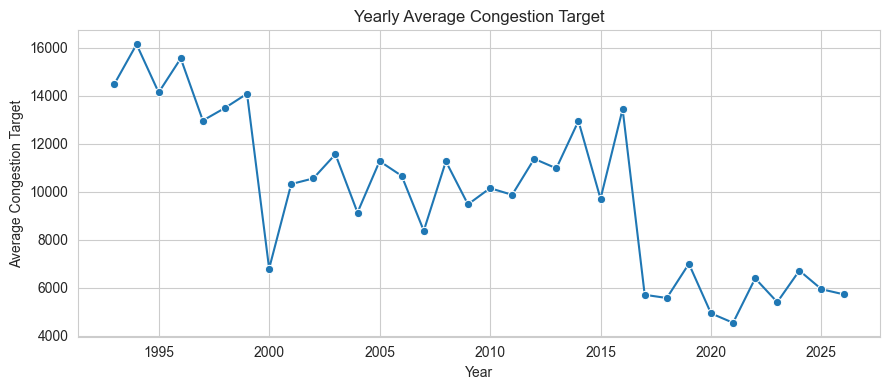

In [8]:
df["count_date_start"] = pd.to_datetime(df["count_date_start"], errors="coerce")
df["count_date_end"] = pd.to_datetime(df["count_date_end"], errors="coerce")

df["year"] = df["count_date_start"].dt.year
df["month"] = df["count_date_start"].dt.month

yearly_congestion = (
    df.dropna(subset=["year", "congestion_target"])
    .groupby("year", as_index=False)["congestion_target"]
    .mean()
)

plt.figure(figsize=(9, 4))
sns.lineplot(data=yearly_congestion, x="year", y="congestion_target", marker="o")
plt.title("Yearly Average Congestion Target")
plt.xlabel("Year")
plt.ylabel("Average Congestion Target")
plt.tight_layout()
plt.show()


The yearly profile summarizes medium-term changes in congestion intensity. Any pronounced drop or shift near 2020 should be treated as a potential structural break consistent with pandemic-era demand disruptions, which may require regime-aware validation and feature design in forecasting models.


# 5. Weekly Seasonality


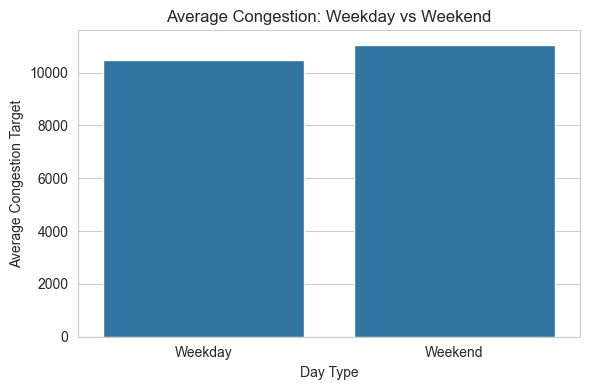

In [9]:
df["day_of_week"] = df["count_date_start"].dt.day_name()
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])
df["day_type"] = df["is_weekend"].map({False: "Weekday", True: "Weekend"})

weekday_weekend = (
    df.dropna(subset=["day_type", "congestion_target"])
    .groupby("day_type", as_index=False)["congestion_target"]
    .mean()
)

plt.figure(figsize=(6, 4))
sns.barplot(data=weekday_weekend, x="day_type", y="congestion_target", order=["Weekday", "Weekend"])
plt.title("Average Congestion: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Congestion Target")
plt.tight_layout()
plt.show()


Weekday-weekend differences indicate recurring weekly seasonality. Stronger weekday congestion would support the inclusion of calendar features (day-of-week and weekend flags) and potentially interaction terms with corridor-specific demand patterns.


# 6. Peak vs Off-Peak Patterns


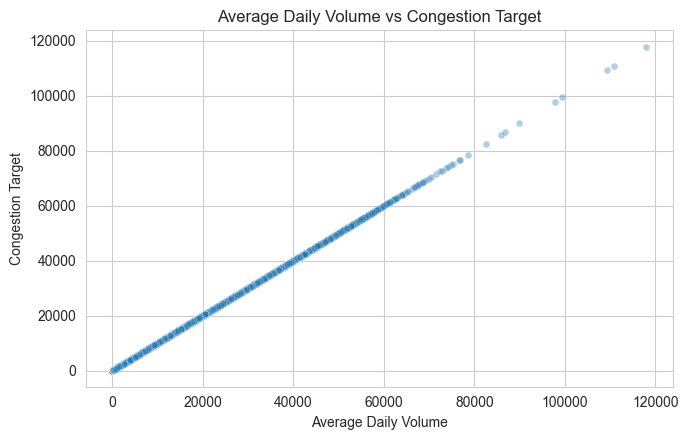

In [10]:
vol_compare = df.dropna(subset=["avg_daily_vol", "congestion_target"])

plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=vol_compare, x="avg_daily_vol", y="congestion_target", alpha=0.35, s=24)
plt.title("Average Daily Volume vs Congestion Target")
plt.xlabel("Average Daily Volume")
plt.ylabel("Congestion Target")
plt.tight_layout()
plt.show()


The scatter profile evaluates how total daily flow scales into peak-period congestion. A positive association is expected and would indicate that peak stress is partly driven by overall volume levels, while dispersion reflects unobserved factors such as geometry, control, and modal mix.


# 7. Speed vs Congestion Relationship


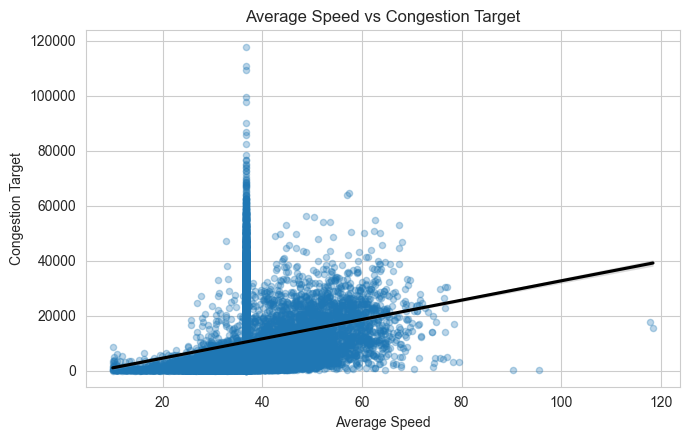

Correlation (avg_speed vs congestion_target): 0.205


In [11]:
speed_compare = df.dropna(subset=["avg_speed", "congestion_target"])
speed_corr = speed_compare[["avg_speed", "congestion_target"]].corr().iloc[0, 1]

plt.figure(figsize=(7, 4.5))
sns.regplot(data=speed_compare, x="avg_speed", y="congestion_target", scatter_kws={"alpha": 0.3, "s": 20}, line_kws={"color": "black"})
plt.title("Average Speed vs Congestion Target")
plt.xlabel("Average Speed")
plt.ylabel("Congestion Target")
plt.tight_layout()
plt.show()

print(f"Correlation (avg_speed vs congestion_target): {speed_corr:.3f}")


A negative speed-congestion relationship would be consistent with classical traffic flow behavior where higher congestion coincides with reduced speeds. This relationship can improve model signal but should be assessed for endogeneity when forecasting future congestion.


# 8. Heavy Vehicle Impact


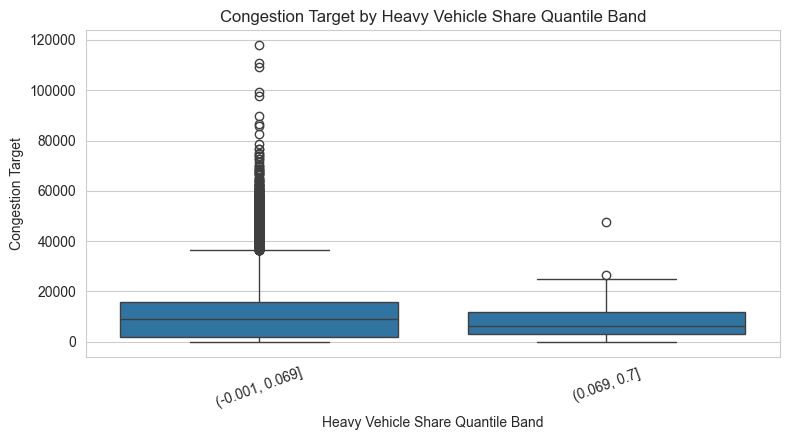

heavy_vehicle_band
(-0.001, 0.069]    10499.120439
(0.069, 0.7]        8085.604396
Name: congestion_target, dtype: float64

In [12]:
heavy_compare = df.dropna(subset=["avg_heavy_pct", "congestion_target"]).copy()
heavy_compare["heavy_vehicle_band"] = pd.qcut(
    heavy_compare["avg_heavy_pct"],
    q=4,
    duplicates="drop",
)

plt.figure(figsize=(8, 4.5))
sns.boxplot(data=heavy_compare, x="heavy_vehicle_band", y="congestion_target")
plt.title("Congestion Target by Heavy Vehicle Share Quantile Band")
plt.xlabel("Heavy Vehicle Share Quantile Band")
plt.ylabel("Congestion Target")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

heavy_compare.groupby("heavy_vehicle_band", observed=False)["congestion_target"].mean()


Differences across heavy-vehicle share bands indicate whether freight composition contributes to peak congestion levels. If upper-share quartiles show higher medians or wider spread, heavy-vehicle intensity should be treated as an important explanatory feature.


# 9. Correlation Matrix


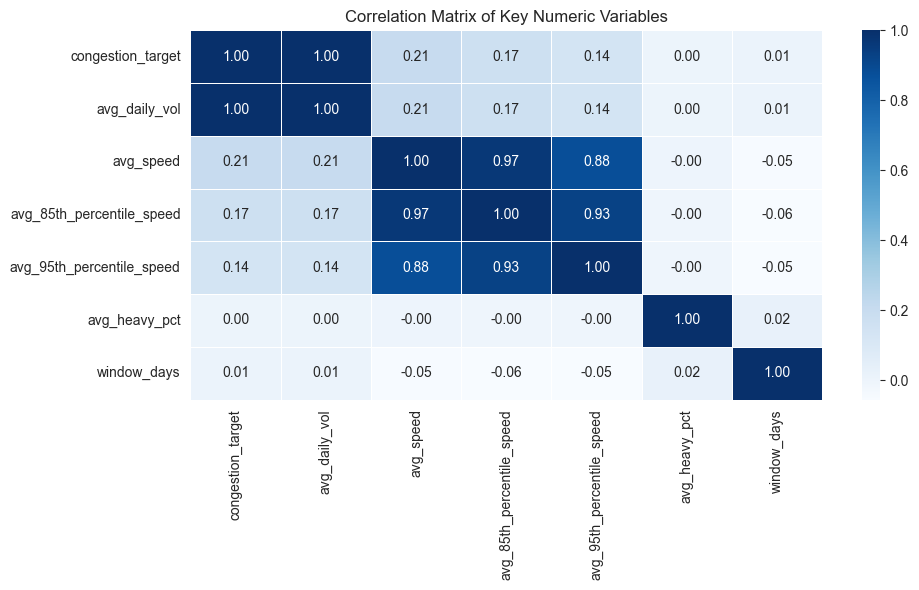

In [13]:
corr_candidates = [
    "congestion_target",
    "avg_wkdy_pm_peak_vol",
    "avg_daily_vol",
    "avg_speed",
    "avg_85th_percentile_speed",
    "avg_95th_percentile_speed",
    "avg_am_peak_vol",
    "avg_wkdy_am_peak_vol",
    "avg_heavy_pct",
    "window_days",
]

if "window_days" not in df.columns:
    df["window_days"] = (df["count_date_end"] - df["count_date_start"]).dt.days

corr_cols = [c for c in corr_candidates if c in df.columns]
corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="Blues", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Numeric Variables")
plt.tight_layout()
plt.show()


The heatmap highlights dominant linear associations and potential multicollinearity. Highly correlated predictors should be managed through feature screening, regularization, or model classes that are robust to collinear inputs.


# 10. Key Insights and Modeling Implications
- Congestion exhibits clear temporal structure, supporting explicit calendar-based features.
- Year-level variation suggests potential regime shifts; time-aware validation is required.
- Weekday and weekend profiles differ, indicating recurring weekly seasonality in demand pressure.
- Higher daily traffic volume aligns with higher peak-period congestion, though with notable heterogeneity.
- Speed metrics carry inverse information about congestion and can add predictive signal.
- Heavy-vehicle share appears behaviorally relevant and should be retained as a candidate feature.
- Correlation structure indicates that some volume and speed variables may be redundant if used simultaneously.

**Implications for feature engineering:** Include calendar terms (year, month, weekday/weekend), traffic intensity variables, speed indicators, and heavy-vehicle composition, with careful handling of collinear predictors.

**Implications for model selection:** Prefer models that handle correlated predictors and nonlinear effects (for example, regularized linear baselines plus tree-based benchmarks).

**Implications for forecasting approach:** Use temporally ordered train-validation splits and evaluate robustness across potential structural-break periods.


In [14]:
if "avg_wkdy_pm_peak_vol" in df.columns:
    target_consistency_max_abs_diff = (df["congestion_target"] - df["avg_wkdy_pm_peak_vol"]).abs().max()
    print(f"Max absolute difference between congestion_target and avg_wkdy_pm_peak_vol: {target_consistency_max_abs_diff:.6f}")

output_path = Path("../data/processed/traffic_summary_eda_ready.csv")
df.to_csv(output_path, index=False)
print(f"Saved EDA-ready dataset to: {output_path}")


Saved EDA-ready dataset to: ../data/processed/traffic_summary_eda_ready.csv
